In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  notebooks/feature_engineering.ipynb                                     ║
# ║  BVMT — TFT Feature Engineering + Full Validation                       ║
# ║                                                                          ║
# ║  PURPOSE: Build the training dataset for the TFT model.                 ║
# ║  This notebook queries PostgreSQL, joins 3 tables, computes the         ║
# ║  prediction target, validates everything, and exports tft_features.csv  ║
# ║                                                                          ║
# ║  RUN ORDER: Cells 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11        ║
# ║  Each cell must PASS before moving to the next.                         ║
# ║  DO NOT skip cells. Each one builds on the previous.                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
 
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports and database connection                               ║
# ║                                                                          ║
# ║  WHAT THIS DOES:                                                         ║
# ║  Loads all Python libraries we need and connects to PostgreSQL.         ║
# ║                                                                          ║
# ║  WHY THESE LIBRARIES:                                                    ║
# ║  - pandas: the main library for working with tables in Python           ║
# ║  - numpy: math operations (used for NaN handling)                       ║
# ║  - psycopg2: connects Python to PostgreSQL                              ║
# ║  - matplotlib: draws charts so we can SEE the data                      ║
# ║  - pathlib: handles file paths cleanly on Windows                       ║
# ║  - dotenv: reads your .env file so passwords are not in the code        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from dotenv import load_dotenv
 
load_dotenv()  # reads DB_HOST, DB_PORT, DB_NAME, DB_USER, DB_PASSWORD from .env
 
# ── Database connection helper ─────────────────────────────────────────────
# We open and close a connection for each query.
# This prevents "connection timed out" errors during long operations.
def get_conn():
    return psycopg2.connect(
        host     = os.getenv('DB_HOST'),
        port     = int(os.getenv('DB_PORT', 5432)),
        dbname   = os.getenv('DB_NAME'),
        user     = os.getenv('DB_USER'),
        password = os.getenv('DB_PASSWORD')
    )
 
# ── Output folder ──────────────────────────────────────────────────────────
OUTPUT_DIR = Path(r'C:\Users\Negza\Desktop\projects\pfe\bvmt_project\data\features')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
# ── Quick connectivity test ────────────────────────────────────────────────
try:
    conn = get_conn()
    with conn.cursor() as cur:
        cur.execute('SELECT COUNT(*) FROM daily_prices')
        n = cur.fetchone()[0]
    conn.close()
    print(f"✓ Connected to PostgreSQL")
    print(f"  daily_prices has {n:,} rows")
except Exception as e:
    print(f"✗ Connection failed: {e}")
    print("  Check your .env file: DB_HOST, DB_PORT, DB_NAME, DB_USER, DB_PASSWORD")
 
 

✓ Connected to PostgreSQL
  daily_prices has 116,626 rows


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Load daily_prices from PostgreSQL                             ║
# ║                                                                          ║
# ║  WHAT THIS DOES:                                                         ║
# ║  Loads all price data for all stocks from 2016 to 2025.                 ║
# ║                                                                          ║
# ║  SIMPLE EXPLANATION:                                                     ║
# ║  Think of daily_prices like a spreadsheet where each row is:            ║
# ║  "On DATE, stock TICKER opened at OPEN, closed at CLOSE,                ║
# ║   reached a LOW of X and a HIGH of Y, with VOLUME shares traded"        ║
# ║                                                                          ║
# ║  WHY WE NEED OHLCV FOR TFT:                                             ║
# ║  The TFT model learns patterns from how prices move over time.          ║
# ║  Open, high, low, close together give more information than just        ║
# ║  the closing price — they show the trading range and volatility          ║
# ║  within each day.                                                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
print("Loading daily_prices... (this takes ~10-20 seconds)")
 
conn = get_conn()
df_prices = pd.read_sql('''
    SELECT
        seance                AS date,
        isin_code,
        ticker,
        ouverture             AS open_price,
        cloture               AS close_price,
        plus_bas              AS low_price,
        plus_haut             AS high_price,
        quantite_negociee     AS volume,
        nb_transaction        AS num_trades
    FROM daily_prices
    ORDER BY ticker, seance
''', conn)
conn.close()
 
# Convert the date column from string to a proper date type
# This allows us to do date arithmetic later (like shift(-7) for the target)
df_prices['date'] = pd.to_datetime(df_prices['date'])
 
print(f"✓ Loaded daily_prices")
print(f"  Rows   : {len(df_prices):,}")
print(f"  Stocks : {df_prices['ticker'].nunique()}")
print(f"  Dates  : {df_prices['date'].min().date()} → {df_prices['date'].max().date()}")
print()
 
# Quick sanity check on the loaded data
zero_close = (df_prices['close_price'] <= 0).sum()
null_close  = df_prices['close_price'].isnull().sum()
print(f"  Zero close prices : {zero_close} (should be 0)")
print(f"  NULL close prices : {null_close} (should be 0)")
 
if zero_close > 0 or null_close > 0:
    print("  ✗ PROBLEM — run the pgAdmin fixes before continuing")
else:
    print("  ✓ Price data looks clean")
 
 

Loading daily_prices... (this takes ~10-20 seconds)
✓ Loaded daily_prices
  Rows   : 116,626
  Stocks : 71
  Dates  : 2016-01-04 → 2025-12-31

  Zero close prices : 0 (should be 0)
  NULL close prices : 0 (should be 0)
  ✓ Price data looks clean


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Load computed_indicators and join with prices                 ║
# ║                                                                          ║
# ║  WHAT THIS DOES:                                                         ║
# ║  Loads technical indicators (MA, RSI, volatility) and combines them     ║
# ║  with the price data into one table.                                     ║
# ║                                                                          ║
# ║  WHAT ARE TECHNICAL INDICATORS?                                          ║
# ║  They are formulas that summarize price history into single numbers.    ║
# ║  Examples:                                                               ║
# ║  - MA20 (20-day Moving Average): average of the last 20 closing prices  ║
# ║    → tells you the medium-term trend direction                          ║
# ║  - RSI14 (Relative Strength Index): measures if a stock is overbought   ║
# ║    (>70) or oversold (<30) based on recent up/down moves                ║
# ║  - volatility_20: how much the price fluctuated in the last 20 days    ║
# ║    → high volatility = risky stock, low = stable stock                  ║
# ║                                                                          ║
# ║  WHY JOIN ON (date, isin_code)?                                          ║
# ║  Each row in both tables represents one stock on one day.               ║
# ║  We join on both date AND isin_code to make sure we match               ║
# ║  the right indicator to the right stock on the right day.               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
print("Loading computed_indicators...")
 
conn = get_conn()
df_ind = pd.read_sql('''
    SELECT
        seance        AS date,
        isin_code,
        ma_5,
        ma_20,
        ma_50,
        rsi_14,
        daily_return,
        volatility_20,
        volume_ma_20
    FROM computed_indicators
    ORDER BY isin_code, seance
''', conn)
conn.close()
 
df_ind['date'] = pd.to_datetime(df_ind['date'])
 
print(f"✓ Loaded computed_indicators: {len(df_ind):,} rows")
print()
print("Joining prices with indicators on (date, isin_code)...")
 
# INNER JOIN: keeps only rows that exist in BOTH tables
# Some early rows in daily_prices are dropped here because indicators
# need a warmup period (MA50 needs 50 days, RSI needs 14 days)
# This is normal and expected — we lose ~50 rows per stock at the start
df = df_prices.merge(df_ind, on=['date', 'isin_code'], how='inner')
 
lost = len(df_prices) - len(df)
lost_pct = lost / len(df_prices) * 100
 
print(f"✓ Join complete")
print(f"  Before join : {len(df_prices):,} rows")
print(f"  After join  : {len(df):,} rows")
print(f"  Lost rows   : {lost:,} ({lost_pct:.1f}%) — normal warmup period")
 
if lost_pct > 20:
    print("  ✗ WARNING: >20% rows lost — possible ISIN mismatch between tables")
    print("    Run: SELECT DISTINCT isin_code FROM daily_prices WHERE isin_code NOT IN")
    print("         (SELECT DISTINCT isin_code FROM computed_indicators)")
else:
    print("  ✓ Join coverage acceptable")
 
 

Loading computed_indicators...
✓ Loaded computed_indicators: 114,365 rows

Joining prices with indicators on (date, isin_code)...
✓ Join complete
  Before join : 116,626 rows
  After join  : 114,365 rows
  Lost rows   : 2,261 (1.9%) — normal warmup period
  ✓ Join coverage acceptable


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Load company_metadata and add static features                 ║
# ║                                                                          ║
# ║  WHAT THIS DOES:                                                         ║
# ║  Adds information about each company that does NOT change over time.    ║
# ║  These are called "static features" in TFT terminology.                 ║
# ║                                                                          ║
# ║  STATIC vs TIME-VARYING FEATURES:                                        ║
# ║  - Static: things that stay the same regardless of date                 ║
# ║    → ticker_id (the number representing this stock)                     ║
# ║    → company_type_id (is it a bank, insurance, or non-bank?)            ║
# ║  - Time-varying: things that change every day                           ║
# ║    → close_price, RSI, MA20, volume, daily_return, etc.                 ║
# ║                                                                          ║
# ║  WHY DOES TFT NEED COMPANY TYPE?                                         ║
# ║  Banks and industrial companies behave differently during market cycles. ║
# ║  Banks are sensitive to interest rates. Industrial stocks to raw        ║
# ║  material prices. Giving TFT this information helps it learn           ║
# ║  different patterns for different types of companies.                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
# Define which stocks are banks and which are insurance companies
# Everything else is classified as non_bank
BANK_TICKERS = {
    'AMEN BANK', 'BIAT', 'BNA', 'STB', 'BH BANK',
    'ATTIJARI BANK', 'ATB', 'UBCI', 'UIB', 'BT',
    'WIFACK INT BANK'
}
INSURANCE_TICKERS = {
    'STAR', 'ASTREE', 'BH ASSURANCE', 'ASSUR MAGHREBIA',
    'ASSU MAGHREBIA VIE', 'TUNIS RE', 'BNA ASSURANCES'
}
 
def get_company_type(ticker):
    """Return 0=bank, 1=insurance, 2=non_bank"""
    if ticker in BANK_TICKERS:
        return 0
    if ticker in INSURANCE_TICKERS:
        return 1
    return 2
 
# Add company_type as a numeric column
df['company_type_id'] = df['ticker'].apply(get_company_type)
 
# Verify distribution
type_dist = df.groupby('company_type_id')['ticker'].nunique()
print("Company type distribution:")
print(f"  Banks (0)      : {type_dist.get(0, 0)} stocks")
print(f"  Insurance (1)  : {type_dist.get(1, 0)} stocks")
print(f"  Non-bank (2)   : {type_dist.get(2, 0)} stocks")
print()
print(f"✓ company_type_id added to all {len(df):,} rows")
 
 

Company type distribution:
  Banks (0)      : 10 stocks
  Insurance (1)  : 5 stocks
  Non-bank (2)   : 56 stocks

✓ company_type_id added to all 114,365 rows


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Filter stocks: remove illiquid and insufficient stocks        ║
# ║                                                                          ║
# ║  WHAT THIS DOES:                                                         ║
# ║  Removes stocks that would hurt model quality:                          ║
# ║  1. Stocks with fewer than 500 trading days (not enough history)        ║
# ║  2. Known illiquid stocks (>30% of days have zero volume)               ║
# ║  3. Stocks listed too recently (not enough data to learn from)          ║
# ║                                                                          ║
# ║  WHY 500 DAYS MINIMUM?                                                   ║
# ║  TFT uses a 60-day encoder window. It needs to see at least 60 days    ║
# ║  of history to make one prediction. With 500 days, the model gets       ║
# ║  440 usable prediction points per stock — enough to learn patterns.    ║
# ║  With only 200 days, it gets 140 points — too few to learn reliably.   ║
# ║                                                                          ║
# ║  WHY EXCLUDE ILLIQUID STOCKS?                                            ║
# ║  Illiquid stocks (HANNIBAL LEASE: 54% zero-volume days) stay at the    ║
# ║  same price for weeks at a time. TFT will learn "price stays flat"      ║
# ║  which is not a useful pattern. Including them adds noise.              ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
print(f"Before filtering: {df['ticker'].nunique()} stocks, {len(df):,} rows")
 
# ── Explicit exclusion list ────────────────────────────────────────────────
# These are excluded regardless of day count
EXCLUDE_TICKERS = {
    'HANNIBAL LEASE',   # 54% zero-volume days — too illiquid
    'SIMPAR',           # 52% zero-volume days — too illiquid
    'CEREALIS',         # only 248 days, 1 year of data
    'AMS',              # only 65 days
    'SERVICOM',         # only 123 days, ended 2021
    'BNA ASSURANCES',   # only 248 days, started 2025
    'OFFICEPLAST',      # only 248 days, started 2025
}
df = df[~df['ticker'].isin(EXCLUDE_TICKERS)]
print(f"After explicit exclusions: {df['ticker'].nunique()} stocks")
 
# ── 500-day minimum filter ─────────────────────────────────────────────────
stock_day_counts = df.groupby('ticker')['date'].count()
valid_tickers    = stock_day_counts[stock_day_counts >= 500].index
removed_tickers  = stock_day_counts[stock_day_counts < 500].index.tolist()
 
df = df[df['ticker'].isin(valid_tickers)]
 
print(f"After 500-day filter: {df['ticker'].nunique()} stocks, {len(df):,} rows")
 
if removed_tickers:
    print(f"  Removed ({len(removed_tickers)} stocks): {removed_tickers}")
else:
    print("  No stocks removed by 500-day filter")
 
print()
print("Remaining stock coverage:")
coverage = df.groupby('ticker')['date'].agg(['count','min','max'])
coverage.columns = ['days','first','last']
coverage = coverage.sort_values('days', ascending=False)
print(coverage.to_string())
 
 

Before filtering: 71 stocks, 114,365 rows
After explicit exclusions: 64 stocks
After 500-day filter: 57 stocks, 108,679 rows
  Removed (7 stocks): ['ASSUR MAGHREBIA', 'BH LEASING', 'CIMENTS DE BIZERTE', 'MODERN LEASING', 'SPDIT - SICAF', 'TAWASOL GP HOLDING', 'TUNISIE VALEURS']

Remaining stock coverage:
                    days      first       last
ticker                                        
BH BANK             2469 2016-02-01 2025-12-31
SFBT                2469 2016-02-01 2025-12-31
ATTIJARI BANK       2468 2016-02-01 2025-12-31
SAH                 2467 2016-02-01 2025-12-31
TPR                 2467 2016-02-01 2025-12-31
SOTUVER             2466 2016-02-01 2025-12-31
BIAT                2466 2016-02-02 2025-12-31
BT                  2466 2016-02-01 2025-12-31
UIB                 2463 2016-02-01 2025-12-31
EURO-CYCLES         2462 2016-02-01 2025-12-31
TELNET HOLDING      2459 2016-02-01 2025-12-31
BNA                 2456 2016-02-01 2025-12-31
SOTUMAG             2450 2016-02-01 

In [7]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Compute the TARGET variable (direction_7d)                   ║
# ║                                                                          ║
# ║  WHAT THIS DOES:                                                         ║
# ║  Creates the column that TFT will learn to predict.                     ║
# ║                                                                          ║
# ║  SIMPLE EXPLANATION:                                                     ║
# ║  For each row (stock on a given day), we look 7 trading days ahead     ║
# ║  and ask: "will the closing price be higher than today?"               ║
# ║  If YES → direction_7d = 1 (UP)                                         ║
# ║  If NO  → direction_7d = 0 (DOWN or flat)                               ║
# ║                                                                          ║
# ║  EXAMPLE:                                                                ║
# ║  AMEN BANK on March 10:  close = 21.50                                  ║
# ║  AMEN BANK on March 19:  close = 22.00  (7 trading days later)         ║
# ║  → direction_7d for March 10 = 1 (price went UP)                        ║
# ║                                                                          ║
# ║  WHY shift(-7) AND NOT shift(7)?                                         ║
# ║  shift(-7) looks FORWARD in time (negative = future)                    ║
# ║  shift(+7) looks BACKWARD in time (positive = past)                     ║
# ║  We want to predict the FUTURE, so we use shift(-7)                     ║
# ║                                                                          ║
# ║  WHY groupby BEFORE shift?                                               ║
# ║  The data has multiple stocks. Without groupby, shift(-7) would         ║
# ║  accidentally grab the price of the NEXT stock instead of the same     ║
# ║  stock 7 days later. groupby('ticker') ensures we only look forward     ║
# ║  within the same stock.                                                  ║
# ║                                                                          ║
# ║  WHY dropna AFTER shift?                                                 ║
# ║  The last 7 rows of each stock have no future price available.          ║
# ║  shift(-7) puts NaN in those rows. dropna removes them.                 ║
# ║  This is correct — we cannot train on rows without a known answer.      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
# CRITICAL: Sort by ticker AND date before shift
# If not sorted, shift(-7) grabs the wrong rows
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)
 
# Step 1: Look 7 trading days ahead within each stock group
df['future_close'] = df.groupby('ticker')['close_price'].shift(-7)
 
# Step 2: Compare future close with today's close
# 1 = price goes UP (future > today)
# 0 = price goes DOWN or stays flat (future <= today)
df['direction_7d'] = (df['future_close'] > df['close_price']).astype(int)
 
# Step 3: Remove the last 7 rows per stock (they have no future price)
rows_before = len(df)
df = df.dropna(subset=['future_close'])
rows_after  = len(df)
rows_dropped = rows_before - rows_after
 
# Step 4: Drop the future_close column — we don't want TFT to see it
# (it would be data leakage: giving the model the answer)
df = df.drop(columns=['future_close'])
 
print(f"✓ direction_7d target computed")
print(f"  Rows before dropna : {rows_before:,}")
print(f"  Rows dropped       : {rows_dropped:,} (last 7 rows per stock — correct)")
print(f"  Rows remaining     : {rows_after:,}")
print()
 
# Class balance check
balance = df['direction_7d'].value_counts(normalize=True)
up_pct  = balance.get(1, 0) * 100
dn_pct  = balance.get(0, 0) * 100
print(f"Class balance (overall):")
print(f"  UP   (1): {up_pct:.1f}%")
print(f"  DOWN (0): {dn_pct:.1f}%")
print()
 
if up_pct > 65:
    print("⚠ WARNING: Strong UP imbalance — add class_weight to training")
    print("  In train_tft.py: use CrossEntropy with weight=[down_ratio, up_ratio]")
elif up_pct < 35:
    print("✗ PROBLEM: Majority DOWN — check if shift(-7) direction is correct")
    print("  direction_7d should be 1 when price goes UP, 0 when DOWN")
else:
    print("✓ Class balance acceptable")
 
# Per-year balance — important for understanding market cycles
print()
print("UP% by year (useful for your thesis):")
df['year'] = df['date'].dt.year
yearly = df.groupby('year')['direction_7d'].mean() * 100
for yr, pct in yearly.items():
    bar   = '█' * int(pct / 5)
    trend = ' ← BULL YEAR' if pct > 60 else (' ← BEAR YEAR' if pct < 40 else '')
    print(f"  {yr}: {pct:5.1f}%  {bar}{trend}")
 
 


✓ direction_7d target computed
  Rows before dropna : 108,679
  Rows dropped       : 399 (last 7 rows per stock — correct)
  Rows remaining     : 108,280

Class balance (overall):
  UP   (1): 42.7%
  DOWN (0): 57.3%

✓ Class balance acceptable

UP% by year (useful for your thesis):
  2016:  42.1%  ████████
  2017:  41.7%  ████████
  2018:  43.1%  ████████
  2019:  37.1%  ███████ ← BEAR YEAR
  2020:  42.1%  ████████
  2021:  41.2%  ████████
  2022:  41.8%  ████████
  2023:  43.2%  ████████
  2024:  46.1%  █████████
  2025:  49.9%  █████████


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Create numeric encodings for TFT                             ║
# ║                                                                          ║
# ║  WHAT THIS DOES:                                                         ║
# ║  TFT cannot work with text (like "AMEN BANK") or dates (like           ║
# ║  "2016-01-04"). It only understands numbers. This cell converts:        ║
# ║  - Ticker names    → integer IDs (0, 1, 2, ... 63)                      ║
# ║  - Dates           → integer time index (days since 2016-01-01)         ║
# ║                                                                          ║
# ║  EXAMPLE:                                                                ║
# ║  'AMEN BANK' → ticker_id = 3                                            ║
# ║  'ARTES'     → ticker_id = 5                                            ║
# ║  2016-01-04  → time_idx  = 3  (3 days after 2016-01-01)                ║
# ║  2017-01-03  → time_idx  = 367                                          ║
# ║                                                                          ║
# ║  WHY A TIME INDEX INSTEAD OF THE ACTUAL DATE?                            ║
# ║  TFT needs a continuously increasing integer to track position in time.  ║
# ║  Using actual dates would require the model to understand calendar       ║
# ║  arithmetic. An integer from 0 to 3500 is simpler and more efficient.  ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
# Encode ticker as integer
# factorize() assigns: first ticker alphabetically = 0, second = 1, etc.
df['ticker_id'], ticker_labels = pd.factorize(df['ticker'])
 
# Save the mapping so we can decode predictions back to ticker names later
ticker_mapping = pd.DataFrame({
    'ticker_id': range(len(ticker_labels)),
    'ticker'   : ticker_labels
})
ticker_mapping.to_csv(OUTPUT_DIR / 'ticker_mapping.csv', index=False)
 
# Create time_idx: number of days since 2016-01-01
origin = pd.Timestamp('2016-01-01')
df['time_idx'] = (df['date'] - origin).dt.days
 
# Verify time_idx is unique per stock (no duplicates)
dup_check = df.groupby(['ticker_id', 'time_idx']).size()
duplicates = dup_check[dup_check > 1]
 
print(f"✓ Encodings created")
print(f"  ticker_id range : 0 to {df['ticker_id'].max()} ({df['ticker_id'].nunique()} stocks)")
print(f"  time_idx range  : {df['time_idx'].min()} to {df['time_idx'].max()}")
print(f"  Duplicate check : {len(duplicates)} duplicates (must be 0)")
print()
print(f"✓ ticker_mapping.csv saved to {OUTPUT_DIR}")
print()
print("Ticker ID mapping (first 15):")
print(ticker_mapping.head(15).to_string(index=False))
 
if len(duplicates) > 0:
    print()
    print("✗ PROBLEM: Duplicate (ticker_id, time_idx) pairs found!")
    print("  This means the same stock has two rows for the same day.")
    print("  Fix: check daily_prices for duplicate (ticker, seance) rows")
 
 


✓ Encodings created
  ticker_id range : 0 to 56 (57 stocks)
  time_idx range  : 31 to 3643
  Duplicate check : 0 duplicates (must be 0)

✓ ticker_mapping.csv saved to C:\Users\Negza\Desktop\projects\pfe\bvmt_project\data\features

Ticker ID mapping (first 15):
 ticker_id             ticker
         0              ADWYA
         1          AMEN BANK
         2              ARTES
         3              ASSAD
         4 ASSU MAGHREBIA VIE
         5                ATB
         6 ATELIER MEUBLE INT
         7                ATL
         8      ATTIJARI BANK
         9   ATTIJARI LEASING
        10            BH BANK
        11               BIAT
        12                BNA
        13                 BT
        14    CARTHAGE CEMENT


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Build the final feature set and validate                     ║
# ║                                                                          ║
# ║  WHAT THIS DOES:                                                         ║
# ║  Selects the final columns that go into the TFT model,                  ║
# ║  drops any remaining NULLs, and runs all sanity checks.                 ║
# ║                                                                          ║
# ║  THE FEATURES EXPLAINED:                                                 ║
# ║                                                                          ║
# ║  REQUIRED BY TFT (non-negotiable):                                       ║
# ║  - time_idx      : integer time position (TFT requirement)              ║
# ║  - ticker_id     : which stock this row belongs to (TFT group ID)       ║
# ║                                                                          ║
# ║  STATIC (company-level, does not change):                                ║
# ║  - company_type_id : bank=0, insurance=1, non_bank=2                    ║
# ║                                                                          ║
# ║  TIME-VARYING PAST (historical, what the model learns from):            ║
# ║  - close_price   : the main price signal                                ║
# ║  - volume        : how many shares were traded                          ║
# ║  - daily_return  : % change from yesterday (= momentum signal)         ║
# ║  - ma_5          : 5-day moving average (short-term trend)             ║
# ║  - ma_20         : 20-day moving average (medium-term trend)           ║
# ║  - ma_50         : 50-day moving average (long-term trend)             ║
# ║  - rsi_14        : RSI momentum indicator (overbought/oversold)        ║
# ║  - volatility_20 : 20-day price volatility (risk signal)               ║
# ║  - volume_ma_20  : 20-day average volume (liquidity signal)            ║
# ║  - open_price    : opening price (gap-up/gap-down signal)              ║
# ║  - high_price    : daily high (intraday range signal)                   ║
# ║  - low_price     : daily low (intraday range signal)                    ║
# ║                                                                          ║
# ║  TARGET (what TFT predicts):                                             ║
# ║  - direction_7d  : 1 = price UP in 7 days, 0 = price DOWN              ║
# ║                                                                          ║
# ║  REFERENCE (not fed to model, kept for analysis):                        ║
# ║  - date          : actual date                                           ║
# ║  - ticker        : ticker string                                         ║
# ║  - isin_code     : ISIN                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
# Select final columns in the correct order
FINAL_COLUMNS = [
    # Required by TFT
    'time_idx',
    'ticker_id',
    # Static feature
    'company_type_id',
    # Time-varying features
    'close_price',
    'open_price',
    'high_price',
    'low_price',
    'volume',
    'daily_return',
    'ma_5',
    'ma_20',
    'ma_50',
    'rsi_14',
    'volatility_20',
    'volume_ma_20',
    # Target
    'direction_7d',
    # Reference columns (not fed to TFT)
    'date',
    'ticker',
    'isin_code',
]
 
df_final = df[FINAL_COLUMNS].copy()
 
# Drop any remaining NaN rows (should be very few or zero)
rows_before_drop = len(df_final)
df_final = df_final.dropna()
rows_dropped = rows_before_drop - len(df_final)
print(f"Dropped {rows_dropped} rows with NaN values")
 
# ── COMPREHENSIVE VALIDATION ────────────────────────────────────────────────
print()
print("=" * 55)
print("FEATURE VALIDATION REPORT")
print("=" * 55)
 
all_pass = True
checks   = []
 
# Check 1: Row count
ok = len(df_final) >= 80_000
checks.append(("Row count >= 80,000",  ok, f"{len(df_final):,} rows"))
 
# Check 2: Stock count
ok = df_final['ticker_id'].nunique() >= 40
checks.append(("Stock count >= 40", ok, f"{df_final['ticker_id'].nunique()} stocks"))
 
# Check 3: No NULLs anywhere
null_count = df_final.isnull().sum().sum()
ok = null_count == 0
checks.append(("Zero NULLs", ok, f"{null_count} nulls found"))
 
# Check 4: time_idx unique per stock
dup_idx = df_final.groupby(['ticker_id','time_idx']).size()
dup_idx = (dup_idx > 1).sum()
ok = dup_idx == 0
checks.append(("time_idx unique per stock", ok, f"{dup_idx} duplicates"))
 
# Check 5: RSI in [0, 100]
bad_rsi = ((df_final['rsi_14'] < 0) | (df_final['rsi_14'] > 100)).sum()
ok = bad_rsi == 0
checks.append(("RSI in [0, 100]", ok, f"{bad_rsi} invalid values"))
 
# Check 6: close_price positive
bad_close = (df_final['close_price'] <= 0).sum()
ok = bad_close == 0
checks.append(("close_price > 0", ok, f"{bad_close} invalid values"))
 
# Check 7: MA values positive
bad_ma = (df_final['ma_20'] <= 0).sum()
ok = bad_ma == 0
checks.append(("MA20 > 0", ok, f"{bad_ma} invalid values"))
 
# Check 8: direction_7d is only 0 or 1
bad_target = (~df_final['direction_7d'].isin([0, 1])).sum()
ok = bad_target == 0
checks.append(("direction_7d is 0 or 1", ok, f"{bad_target} invalid values"))
 
# Check 9: class balance
up_pct = df_final['direction_7d'].mean() * 100
ok = 35 <= up_pct <= 65
checks.append(("Class balance 35-65%", ok, f"UP={up_pct:.1f}%"))
 
# Check 10: min rows per stock
min_rows = df_final.groupby('ticker_id').size().min()
ok = min_rows >= 400
checks.append(("Min rows/stock >= 400", ok, f"min={min_rows} rows"))
 
# Check 11: leakage — split overlap
train_dates = set(df_final[df_final['date'] < '2024-01-01']['date'])
val_dates   = set(df_final[(df_final['date'] >= '2024-01-01') & (df_final['date'] < '2025-01-01')]['date'])
test_dates  = set(df_final[df_final['date'] >= '2025-01-01']['date'])
tv_overlap  = len(train_dates & val_dates)
vt_overlap  = len(val_dates   & test_dates)
ok = tv_overlap == 0 and vt_overlap == 0
checks.append(("No train/val/test overlap", ok, f"TV={tv_overlap}, VT={vt_overlap} shared dates"))
 
# Print results
for name, passed, detail in checks:
    icon = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {icon}  {name:<35} {detail}")
    if not passed:
        all_pass = False
 
print()
if all_pass:
    print("✅ ALL CHECKS PASSED — ready to export")
else:
    print("❌ SOME CHECKS FAILED — fix before exporting")
    print("   Do not proceed to training with failed checks")
 
 

Dropped 3090 rows with NaN values

FEATURE VALIDATION REPORT
  ✓ PASS  Row count >= 80,000                 105,190 rows
  ✓ PASS  Stock count >= 40                   57 stocks
  ✓ PASS  Zero NULLs                          0 nulls found
  ✓ PASS  time_idx unique per stock           0 duplicates
  ✓ PASS  RSI in [0, 100]                     0 invalid values
  ✓ PASS  close_price > 0                     0 invalid values
  ✓ PASS  MA20 > 0                            0 invalid values
  ✓ PASS  direction_7d is 0 or 1              0 invalid values
  ✓ PASS  Class balance 35-65%                UP=42.7%
  ✓ PASS  Min rows/stock >= 400               min=513 rows
  ✓ PASS  No train/val/test overlap           TV=0, VT=0 shared dates

✅ ALL CHECKS PASSED — ready to export


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Leakage verification (detailed)                              ║
# ║                                                                          ║
# ║  WHAT IS DATA LEAKAGE?                                                   ║
# ║  Leakage = accidentally giving the model future information during       ║
# ║  training. This makes training accuracy look very high (80%+) but       ║
# ║  the model completely fails on new data.                                 ║
# ║                                                                          ║
# ║  EXAMPLE OF LEAKAGE:                                                     ║
# ║  Imagine you computed direction_7d for the whole dataset, then split.   ║
# ║  If March 2024 training data's direction_7d uses prices from March      ║
# ║  2024 validation set → the model saw future prices during training.     ║
# ║                                                                          ║
# ║  HOW WE PREVENT IT:                                                      ║
# ║  1. direction_7d was computed with shift(-7) WITHIN each ticker group   ║
# ║  2. The last 7 rows of each stock were dropped (no future available)    ║
# ║  3. Train/Val/Test splits are based on DATE only (no stock mixing)      ║
# ║                                                                          ║
# ║  THIS CELL VERIFIES ALL THREE.                                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
print("=" * 55)
print("LEAKAGE VERIFICATION")
print("=" * 55)
print()
 
# Split boundaries
train = df_final[df_final['date'] < '2024-01-01']
val   = df_final[(df_final['date'] >= '2024-01-01') & (df_final['date'] < '2025-01-01')]
test  = df_final[df_final['date'] >= '2025-01-01']
 
print("Split sizes:")
print(f"  Train (2016-2023): {len(train):,} rows  "
      f"{train['date'].min().date()} → {train['date'].max().date()}")
print(f"  Val   (2024)     : {len(val):,} rows  "
      f"{val['date'].min().date()} → {val['date'].max().date()}")
print(f"  Test  (2025)     : {len(test):,} rows  "
      f"{test['date'].min().date()} → {test['date'].max().date()}")
print()
 
# Overlap check
tv_overlap = len(set(train['date']) & set(val['date']))
vt_overlap = len(set(val['date'])   & set(test['date']))
print(f"Train/Val date overlap  : {tv_overlap} (must be 0)")
print(f"Val/Test date overlap   : {vt_overlap} (must be 0)")
print()
 
# Verify last 7 rows per stock were dropped
# The last available date in df_final should be 7+ trading days before
# the last date in daily_prices (before dropna was applied)
conn = get_conn()
with conn.cursor() as cur:
    cur.execute("SELECT MAX(seance) FROM daily_prices")
    max_db_date = pd.Timestamp(cur.fetchone()[0])
conn.close()
 
max_feature_date  = df_final['date'].max()
days_gap          = (max_db_date - max_feature_date).days
 
print(f"Last date in daily_prices  : {max_db_date.date()}")
print(f"Last date in tft_features  : {max_feature_date.date()}")
print(f"Gap (calendar days)        : {days_gap}")
if days_gap >= 7:
    print("✓ PASS: At least 7 days gap — last rows correctly dropped")
else:
    print("✗ WARNING: Gap < 7 days — check that dropna(subset=['future_close']) ran")
 
print()
 
# Verify shift(-7) was done per group: manually check AMEN BANK
amen = df_final[df_final['ticker'] == 'AMEN BANK'].sort_values('date')
print("Manual check — AMEN BANK last 10 rows:")
print("(direction_7d should be valid 0/1 values, not NaN)")
print(amen[['date','close_price','direction_7d']].tail(10).to_string(index=False))
print()
 
if tv_overlap == 0 and vt_overlap == 0 and days_gap >= 7:
    print("✅ LEAKAGE CHECK PASSED — no data leakage detected")
else:
    print("❌ LEAKAGE CHECK FAILED — fix before training")
 
 

LEAKAGE VERIFICATION

Split sizes:
  Train (2016-2023): 84,648 rows  2016-03-14 → 2023-12-29
  Val   (2024)     : 10,228 rows  2024-01-02 → 2024-12-31
  Test  (2025)     : 10,314 rows  2025-01-02 → 2025-12-22

Train/Val date overlap  : 0 (must be 0)
Val/Test date overlap   : 0 (must be 0)

Last date in daily_prices  : 2025-12-31
Last date in tft_features  : 2025-12-22
Gap (calendar days)        : 9
✓ PASS: At least 7 days gap — last rows correctly dropped

Manual check — AMEN BANK last 10 rows:
(direction_7d should be valid 0/1 values, not NaN)
      date  close_price  direction_7d
2025-12-08        47.80             0
2025-12-09        47.45             1
2025-12-10        47.79             0
2025-12-11        47.75             0
2025-12-12        47.80             0
2025-12-15        47.50             1
2025-12-16        47.50             1
2025-12-18        47.76             1
2025-12-19        47.76             1
2025-12-22        47.50             1

✅ LEAKAGE CHECK PASSED — no da

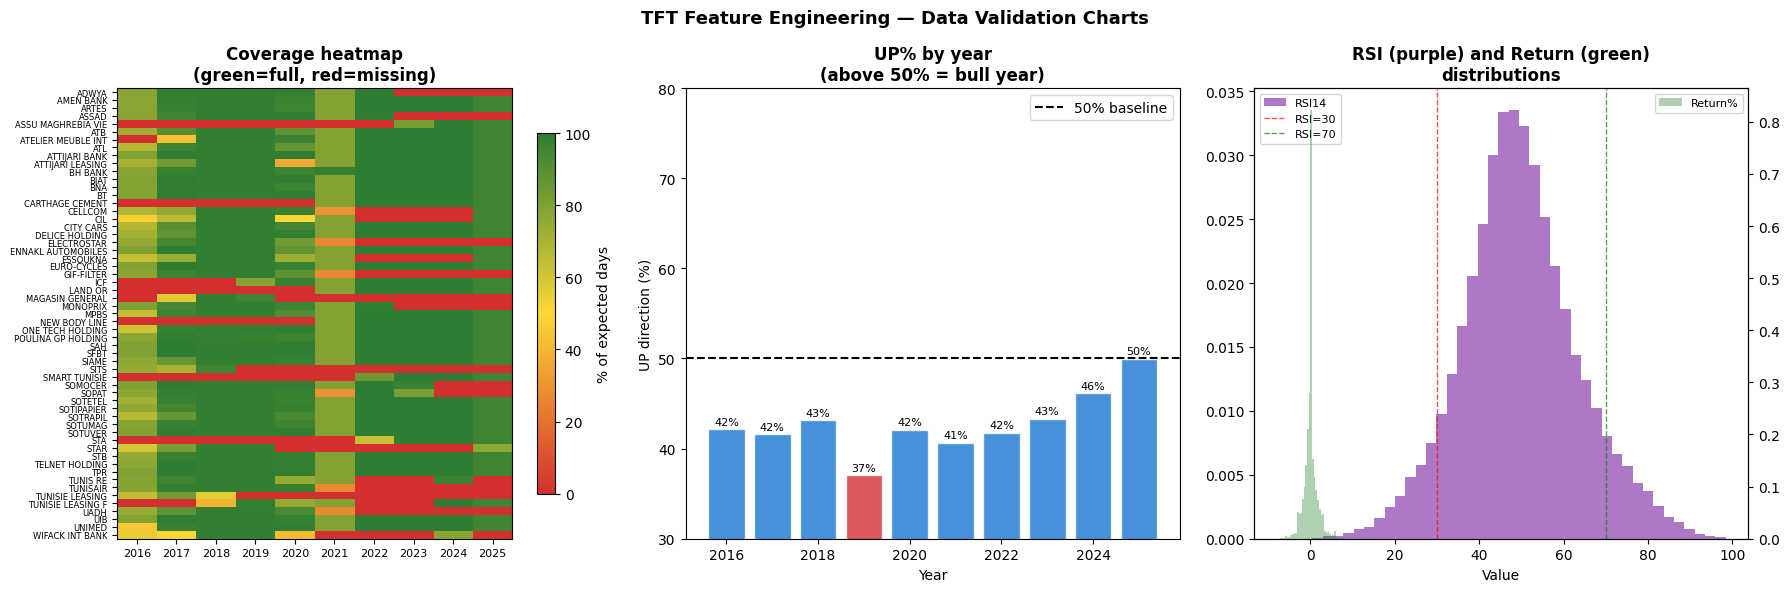

✓ Charts saved to C:\Users\Negza\Desktop\projects\pfe\bvmt_project\data\features\feature_validation_charts.png


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Visual checks (charts)                                       ║
# ║                                                                          ║
# ║  WHAT THIS DOES:                                                         ║
# ║  Draws 3 charts that let you visually verify the data looks correct.   ║
# ║  Charts are much faster to interpret than numbers for spotting issues.  ║
# ║                                                                          ║
# ║  CHART 1 — Coverage heatmap:                                             ║
# ║  Shows which stocks have data for which years.                          ║
# ║  Green = full year, Yellow = partial year, Red = missing year.          ║
# ║  Any RED in your key stocks is a warning sign.                          ║
# ║                                                                          ║
# ║  CHART 2 — Class balance by year:                                        ║
# ║  Shows what % of days were UP each year.                                ║
# ║  A dashed line at 50% shows the neutral level.                          ║
# ║  Years above 50% were bull years, below 50% were bear years.           ║
# ║                                                                          ║
# ║  CHART 3 — Feature distributions:                                        ║
# ║  Shows histograms of RSI and daily_return.                              ║
# ║  RSI should form a bell curve centered near 45-55.                      ║
# ║  daily_return should form a narrow bell curve near 0%.                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('TFT Feature Engineering — Data Validation Charts', fontsize=13, fontweight='bold')
 
# ── CHART 1: Coverage heatmap ─────────────────────────────────────────────
df_final['year'] = df_final['date'].dt.year
coverage_matrix  = df_final.groupby(['ticker','year'])['date'].count().unstack(fill_value=0)
coverage_pct     = (coverage_matrix / 252 * 100).clip(0, 100)
 
cmap = mcolors.LinearSegmentedColormap.from_list('rg', ['#d32f2f','#fdd835','#2e7d32'])
im   = axes[0].imshow(coverage_pct.values, aspect='auto', cmap=cmap, vmin=0, vmax=100)
axes[0].set_xticks(range(len(coverage_pct.columns)))
axes[0].set_xticklabels(coverage_pct.columns, fontsize=8)
axes[0].set_yticks(range(len(coverage_pct.index)))
axes[0].set_yticklabels(coverage_pct.index, fontsize=6)
axes[0].set_title('Coverage heatmap\n(green=full, red=missing)', fontweight='bold')
plt.colorbar(im, ax=axes[0], label='% of expected days', shrink=0.8)
 
# ── CHART 2: Class balance by year ───────────────────────────────────────
yearly_bal = df_final.groupby('year')['direction_7d'].mean() * 100
axes[1].bar(yearly_bal.index, yearly_bal.values,
            color=['#d32f2f' if v < 40 else '#2e7d32' if v > 60 else '#1976d2' for v in yearly_bal.values],
            alpha=0.8, edgecolor='white')
axes[1].axhline(50, color='black', linestyle='--', linewidth=1.5, label='50% baseline')
axes[1].set_title('UP% by year\n(above 50% = bull year)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('UP direction (%)')
axes[1].legend()
axes[1].set_ylim(30, 80)
for yr, val in zip(yearly_bal.index, yearly_bal.values):
    axes[1].text(yr, val + 0.5, f'{val:.0f}%', ha='center', fontsize=8)
 
# ── CHART 3: Feature distributions ───────────────────────────────────────
axes[2].hist(df_final['rsi_14'], bins=40, color='#7b1fa2', alpha=0.6,
             label='RSI14', density=True)
ax2 = axes[2].twinx()
ret_pct = df_final['daily_return'] * 100
ax2.hist(ret_pct.clip(-8, 8), bins=40, color='#388e3c', alpha=0.4,
         label='Return%', density=True)
axes[2].axvline(30, color='red',   linestyle='--', linewidth=1, alpha=0.7, label='RSI=30')
axes[2].axvline(70, color='green', linestyle='--', linewidth=1, alpha=0.7, label='RSI=70')
axes[2].set_title('RSI (purple) and Return (green)\ndistributions', fontweight='bold')
axes[2].set_xlabel('Value')
axes[2].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)
 
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_validation_charts.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Charts saved to {OUTPUT_DIR / 'feature_validation_charts.png'}")
 
 

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Export final CSV and print training summary                  ║
# ║                                                                          ║
# ║  WHAT THIS DOES:                                                         ║
# ║  Saves the final cleaned dataset to a CSV file ready for TFT training.  ║
# ║                                                                          ║
# ║  WHAT GETS SAVED:                                                        ║
# ║  - tft_features.csv   : the main training file (upload to Lightning AI) ║
# ║  - ticker_mapping.csv : maps ticker_id back to company names            ║
# ║                                                                          ║
# ║  THE FINAL GO/NO-GO DECISION:                                            ║
# ║  This cell gives you a clear YES or NO for launching training.          ║
# ║  If it prints GO → upload to Lightning AI and run train_tft.py          ║
# ║  If it prints NO-GO → fix the failed checks above first                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
csv_path = OUTPUT_DIR / 'tft_features.csv'
df_final.to_csv(csv_path, index=False)
 
file_size_mb = csv_path.stat().st_size / 1024 / 1024
 
print("=" * 55)
print("EXPORT COMPLETE")
print("=" * 55)
print(f"  File    : {csv_path}")
print(f"  Size    : {file_size_mb:.1f} MB")
print(f"  Rows    : {len(df_final):,}")
print(f"  Stocks  : {df_final['ticker_id'].nunique()}")
print(f"  Columns : {len(df_final.columns)}")
print(f"  Features: {', '.join([c for c in FINAL_COLUMNS if c not in ['date','ticker','isin_code','direction_7d']])}")
print()
 
# Final split sizes for training
train_size = len(df_final[df_final['date'] <  '2024-01-01'])
val_size   = len(df_final[(df_final['date'] >= '2024-01-01') & (df_final['date'] < '2025-01-01')])
test_size  = len(df_final[df_final['date'] >= '2025-01-01'])
 
print("Training split breakdown:")
print(f"  Train (2016-2023): {train_size:,} rows ({train_size/len(df_final)*100:.0f}%)")
print(f"  Val   (2024)     : {val_size:,} rows ({val_size/len(df_final)*100:.0f}%)")
print(f"  Test  (2025)     : {test_size:,} rows ({test_size/len(df_final)*100:.0f}%)")
print()
 
up_pct = df_final['direction_7d'].mean() * 100
print(f"Class balance      : UP={up_pct:.1f}%  DOWN={100-up_pct:.1f}%")
if up_pct > 65:
    print("  → Add class_weight to train_tft.py (see guide)")
print()
 
# Final GO / NO-GO
print("=" * 55)
if all_pass:
    print("✅  GO — Upload tft_features.csv to Lightning AI")
    print("         and run training/train_tft.py")
    print()
    print("  Upload these 2 files to Lightning AI:")
    print(f"  1. {csv_path}")
    print(f"  2. {OUTPUT_DIR / 'ticker_mapping.csv'}")
else:
    print("❌  NO-GO — Fix the failed checks above before training")
    print("   Scroll up to Cell 8 to see which checks failed")
print("=" * 55)

EXPORT COMPLETE
  File    : C:\Users\Negza\Desktop\projects\pfe\bvmt_project\data\features\tft_features.csv
  Size    : 12.9 MB
  Rows    : 105,190
  Stocks  : 57
  Columns : 20
  Features: time_idx, ticker_id, company_type_id, close_price, open_price, high_price, low_price, volume, daily_return, ma_5, ma_20, ma_50, rsi_14, volatility_20, volume_ma_20

Training split breakdown:
  Train (2016-2023): 84,648 rows (80%)
  Val   (2024)     : 10,228 rows (10%)
  Test  (2025)     : 10,314 rows (10%)

Class balance      : UP=42.7%  DOWN=57.3%

✅  GO — Upload tft_features.csv to Lightning AI
         and run training/train_tft.py

  Upload these 2 files to Lightning AI:
  1. C:\Users\Negza\Desktop\projects\pfe\bvmt_project\data\features\tft_features.csv
  2. C:\Users\Negza\Desktop\projects\pfe\bvmt_project\data\features\ticker_mapping.csv
